# Анализ сходимости метода Якоби для $y''+y'+50y=1$ на отрезке $[0,1]$


In [104]:
import numpy as np
import matplotlib.pyplot as plt

In [154]:
n_hist=[]
iter_hist=[]
print("сброс")

сброс


In [188]:
n = 32
a = 0
bx = 1
y0 = 0
y1 = 1
epz = 0.001
k=10000

### Пишем генератор матриц СЛАУ для уравнения

In [189]:
h = (bx - a) / (n + 1)
A = np.zeros((n, n))
b = np.full((n, 1), 1.0 * h ** 2)
for i in range(n):
    A[i, i] = -2.0 + k * (h ** 2)
    if i > 0:
        A[i, i - 1] = 1.0 - h / 2.0
    else:
        b[i, 0] -= 1.0 - h / 2.0 * y0
    if i < n - 1:
        A[i, i + 1] = 1.0 + h / 2.0
    else:
        b[i, 0] -= (1.0 + h / 2.0) * y1
print(f"генератоp, k={k}, n={n}")

генератоp, k=10000, n=32


### Решаем матрицу итерационно (методом якоби)

In [190]:
tau=(1.0/np.diag(A)).reshape(-1,1)
x=np.zeros((n,1))
err=[]
iter_needed=10000
r=np.zeros((n,1))
for i in range(100000):
  r=b-A@x
  curr_norm=np.linalg.norm(r)
  err.append(curr_norm)
  if curr_norm < epz:
        print("успех")
        iter_needed = i        
        break
  if curr_norm>100000:
      iter_needed=i
      print("расход")
      break
  x=x+tau*r
x_all=np.concatenate(([y0],x.flatten(),[y1]))
n_hist.append(n)
iter_hist.append(iter_needed)

успех


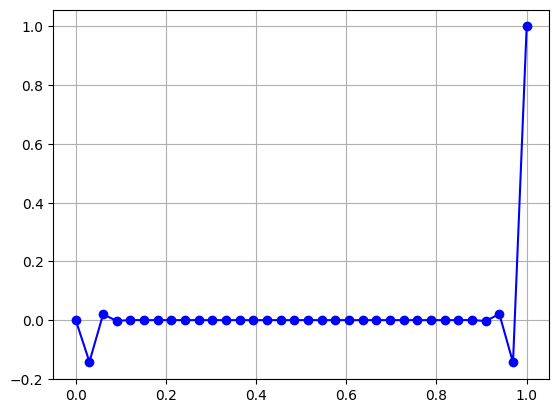

In [195]:
nd=[]
for i in range (n+2):
 nd.append(i*h)
plt.plot(nd, x_all, '-o', color='blue')
plt.grid(True) 
plt.show()

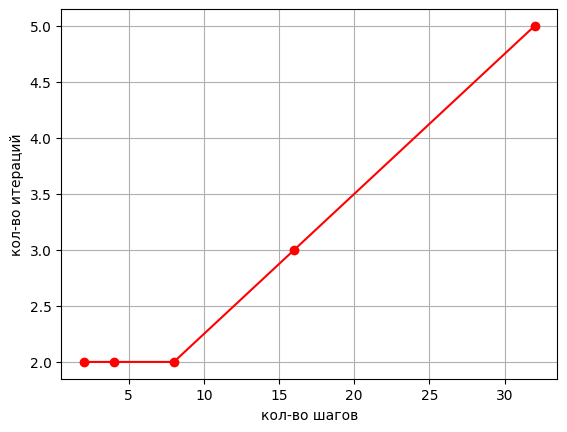

In [180]:
n_hist=[2, 4, 8, 16, 32]
iter_hist=[2, 2, 2, 3, 5]
plt.plot(n_hist, iter_hist, '-o', color='red')
plt.xlabel('кол-во шагов')
plt.ylabel('кол-во итераций')
plt.grid(True) 
plt.show()